In [ ]:
# Block 1: SCPI Server Setup
import pyvisa
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# *** TO DO: adapt IP address and SCPI port according to your needs ***
SCPI_server_IP = 'Server IP given by SCPI server'
SCPI_Port = '5025'

SCPI_timeout = 20000  # milliseconds
VISA_resource_name = 'TCPIP::' + SCPI_server_IP + '::' + SCPI_Port + '::SOCKET'

# Measurement configuration
Start_frequency = '10Hz'
Stop_frequency = '1000KHz'
Number_of_measurement_points = 601  # the minimum amount of measurement points is 2!
Sweep_type = 'LOG'
Receiver_bandwidth = '300Hz'

def perform_measurement():
    start_time = time.time()
    print(
        'Trying to connect to VISA resource: ' + VISA_resource_name + 
        '. Be sure that IP address and port number are correct!')
    visaSession = pyvisa.ResourceManager().open_resource(VISA_resource_name)
    visaSession.timeout = SCPI_timeout
    visaSession.read_termination = '\n'

    print('SCPI client connected to SCPI server: ' + visaSession.query("*IDN?"))

    lockOk = visaSession.query(":SYST:LOCK:REQ?")
    if lockOk != "1":
        print("Locking was not successful, exiting!")
        return None, None, None
    else:
        print("Locking was successful!")
    try:
        ### Here comes the measurement configuration data for measurement sweep
        visaSession.write(':SENS:FREQ:STAR ' + Start_frequency)
        visaSession.write(':SENS:FREQ:STOP ' + str(Stop_frequency))
        visaSession.write(':SENS:SWE:POIN ' + str(Number_of_measurement_points))
        visaSession.write(':SENS:SWE:TYPE ' + Sweep_type)
        visaSession.write(':SENS:BAND ' + Receiver_bandwidth)

        # configuring 'one-port' impedance measurement
        visaSession.write(':CALC:PAR:DEF Z')
        # linear magnitude in Ohms + phase(deg)
        visaSession.write(":CALC:FORM SLIN")

        # Intializes trigger system to use BUS as source
        visaSession.write(':TRIG:SOUR BUS')
        # Sets the trigger in continous mode.
        visaSession.write(':INIT:CONT ON')

        visaSession.write(':TRIG:SING')
        # This command waits for all pending operations to finish
        visaSession.query('*OPC?')
        # Query the measurement results
        allResults = visaSession.query(":CALC:DATA:SDAT?")
        frequencyValues = visaSession.query(":SENS:FREQ:DATA?")

        # Magnitude and phase from the results
        allResults_list_raw = list(map(float, allResults.split(",")))
        magnitude_raw = allResults_list_raw[0:Number_of_measurement_points]
        phase_raw = allResults_list_raw[Number_of_measurement_points:len(allResults_list_raw)]

        # Same procedure with frequency raw data to list and eventually to array
        freq_list_raw = list(map(float, frequencyValues.split(",")))

        # Printing just the first results of the measurement cycle as example
        print("Frequency: " + str(freq_list_raw[0]) + " Hz;" + "\tMagnitude: " 
              + str(magnitude_raw[0]) 
              + " Ω;" + "\tPhase: " + str(phase_raw[0]) + "°")
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None, None
    finally:
        # Release the device
        relOK = visaSession.query(':SYSTem:LOCK:RELease?')
        visaSession.query('*OPC?')
        if relOK != "1":
            print("Releasing was not successful, check the availability of the device!")
        else:
            print("Releasing was successful!")

        visaSession.close()
        print("---Measurement time: %s seconds ---" % (time.time() - start_time))
        return freq_list_raw, magnitude_raw, phase_raw

In [85]:
# Block 2: First Measurement with C1 = 1μF
print("Running measurement with C1 = 1μF")
freq1, mag1, phase1 = perform_measurement()
#save to csv file 
np.savetxt("1uF.csv", np.column_stack((freq1, mag1, phase1)), delimiter=",", header="Frequency, Magnitude, Phase", comments='')

Running measurement with C1 = 1μF
Trying to connect to VISA resource: TCPIP::10.174.192.70::5025::SOCKET. Be sure that IP address and port number are correct!
SCPI client connected to SCPI server: OmicronLab,Bode100R1,LG278C,2.0
Locking was successful!
Frequency: 10.0 Hz;	Magnitude: 0.50940999123 Ω;	Phase: 40.024939726°
Releasing was successful!
---Measurement time: 39.37031030654907 seconds ---


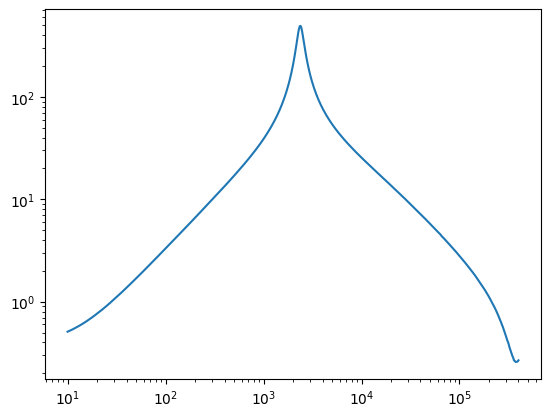

In [86]:
plt.figure()
plt.loglog(freq1, mag1)
plt.show()

In [93]:
# Block 3: Second Measurement with C2 = 100nF
print("\nRunning measurement with C2 = 100nF")
freq2, mag2, phase2 = perform_measurement()
# save to csv file
np.savetxt("100nF.csv", np.column_stack((freq2, mag2, phase2)), delimiter=",", header="Frequency, Magnitude, Phase", comments='')


Running measurement with C2 = 100nF
Trying to connect to VISA resource: TCPIP::10.174.192.70::5025::SOCKET. Be sure that IP address and port number are correct!
SCPI client connected to SCPI server: OmicronLab,Bode100R1,LG278C,2.0
Locking was successful!
Frequency: 10.0 Hz;	Magnitude: 0.50660345727 Ω;	Phase: 40.246881301°
Releasing was successful!
---Measurement time: 39.15408945083618 seconds ---


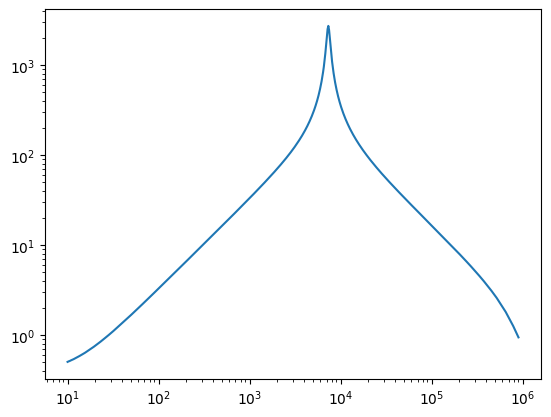

In [94]:
plt.figure()
plt.loglog(freq2, mag2)
plt.show()


Running measurement with no capacitor
Trying to connect to VISA resource: TCPIP::10.174.192.70::5025::SOCKET. Be sure that IP address and port number are correct!
SCPI client connected to SCPI server: OmicronLab,Bode100R1,LG278C,2.0
Locking was successful!
Frequency: 10.0 Hz;	Magnitude: 0.50592695985 Ω;	Phase: 40.32093077°
Releasing was successful!
---Measurement time: 36.89876675605774 seconds ---


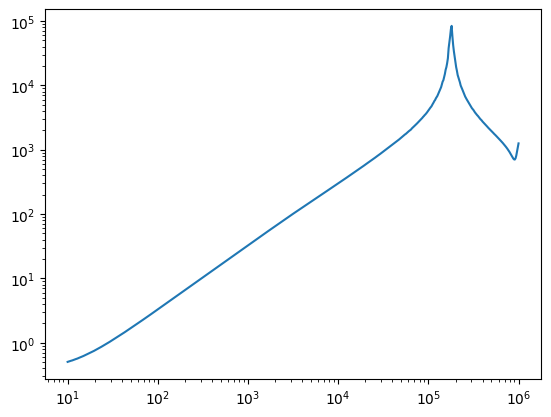

In [100]:
# Block 3.1: Third Measurement with no capacitor
print("\nRunning measurement with no capacitor")
freq3, mag3, phase3 = perform_measurement()
#Save to csv file
np.savetxt("NoCap.csv", np.column_stack((freq3, mag3, phase3)), delimiter=",", header="Frequency, Magnitude, Phase", comments='')
plt.figure()
plt.loglog(freq3, mag3)
plt.show()

Resonant frequency (C1): 2386.33 Hz, Maximum impedance: 493.14 Ω
Resonant frequency (C2): 7331.68 Hz, Maximum impedance: 2727.41 Ω
Resonant frequency (No Capacitor): 181273.09 Hz, Maximum impedance: 83701.36 Ω

Inductance calculation using No Capacitor (slope between 100-10000 Hz):
  Linear fit: |Z| = 0.0304f + 1.9659
  Slope: 0.0304 Ω/Hz
  Inductance: 4.83 mH
Q factor with C1 = 1μF:  249.88042519643042
Q factor with C2 = 100nF:  767.7234837518101
Q factor with no capacitor:  18981.676785222404


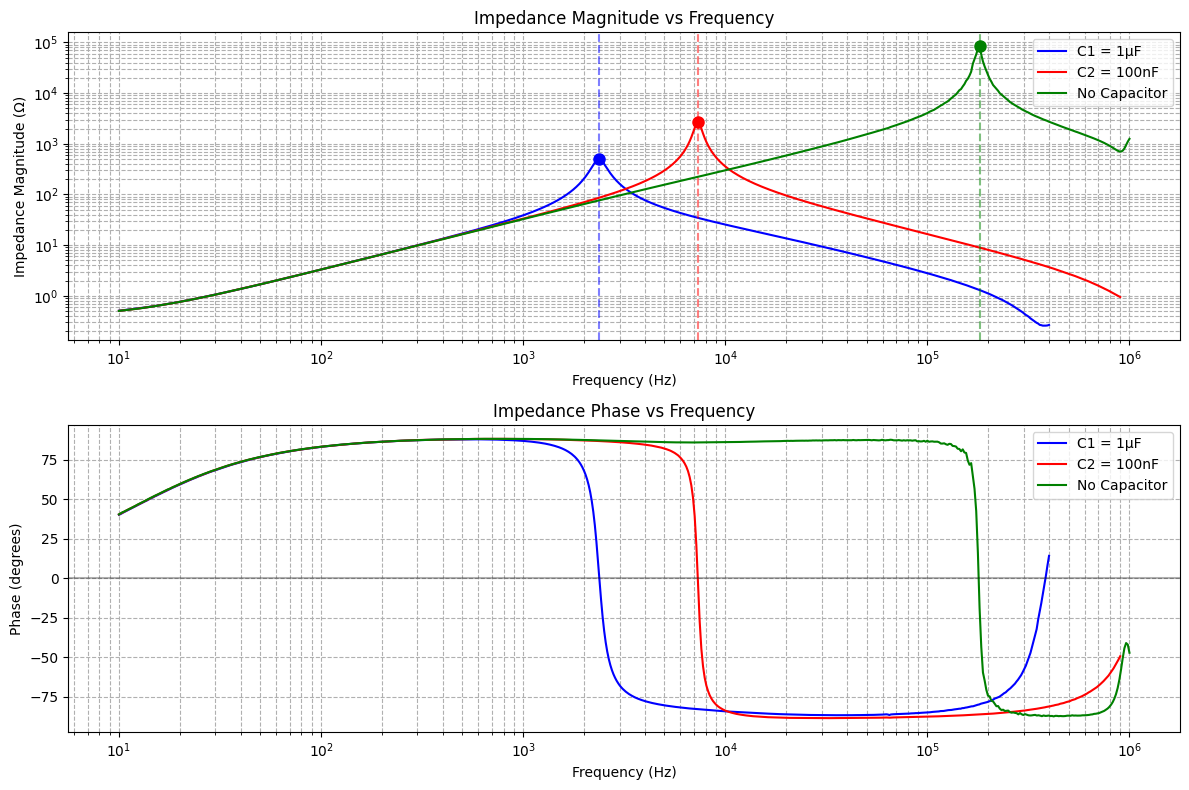

In [ ]:
# Block 4: Analysis and Plotting
import numpy as np
import matplotlib.pyplot as plt

fre1 = np.loadtxt("1uF.csv", delimiter=",", skiprows=1)
fre2 = np.loadtxt("100nF.csv", delimiter=",", skiprows=1)
fre3 = np.loadtxt("NoCap.csv", delimiter=",", skiprows=1)
freq1 = [n for n in fre1[:,0]]
mag1 = [n for n in fre1[:,1]]
phase1 = [n for n in fre1[:,2]]
freq2 = [n for n in fre2[:,0]]
mag2 = [n for n in fre2[:,1]]
phase2 = [n for n in fre2[:,2]]
freq3 = [n for n in fre3[:,0]]
mag3 = [n for n in fre3[:,1]]
phase3 = [n for n in fre3[:,2] ]

# Find resonant frequencies by finding MAXIMUM impedance magnitude (for parallel resonance)
    # Find maximum impedance (peak in the bode plot)
max_idx1 = mag1.index(max(mag1))
fr1 = freq1[max_idx1]
z_max1 = mag1[max_idx1]
print(f"Resonant frequency (C1): {fr1:.2f} Hz, Maximum impedance: {z_max1:.2f} Ω")

# Find maximum impedance (peak in the bode plot)
max_idx2 = mag2.index(max(mag2))
fr2 = freq2[max_idx2]
z_max2 = mag2[max_idx2]
print(f"Resonant frequency (C2): {fr2:.2f} Hz, Maximum impedance: {z_max2:.2f} Ω")
    
# Find maximum impedance (peak in the bode plot)
max_idx3 = mag3.index(max(mag3))
fr3 = freq3[max_idx3]
z_max3 = mag3[max_idx3]
print(f"Resonant frequency (No Capacitor): {fr3:.2f} Hz, Maximum impedance: {z_max3:.2f} Ω")


'''
Invalid way of calculating the EPC and L

# Calculate component values if resonant frequencies were found
if fr1 and fr2:
    # Given values
    C1 = 1e-6  # 1μF
    C2 = 100e-9  # 100nF
    
    # Calculate inductance using equation 
    # fr = 1/(2π√(L[C+Cp]))
    # Two measurements with different capacitors allow us to solve for L
    
    # Using the formula derived
    # (fr2/fr1)^2 = (C1+Cp)/(C2+Cp)
    # Solve for Cp (Equivalent Parallel Capacitance)
    ratio_sq = (fr2/fr1)**2
    Cp = (C1 - ratio_sq * C2) / (ratio_sq - 1)
    print(f"Equivalent Parallel Capacitance (Cp): {Cp*1e9:.2f} nF")
    
    # Calculate inductance using fr1 and total capacitance (C1 + Cp)
    L = 1 / ((2 * np.pi * fr1)**2 * (C1 + Cp))
    print(f"Inductance (L): {L*1e3:.2f} mH")
    
    # Calculate Slope of the plot at 100Hz to 300Hz by fitting to a line
    

if fr3:
    L_wc = 1 / (2 * np.pi * fr3)
    print(f"Inductance without cap (L_wc): {L*1e3:.2f} mH")
    
    # using fr = 1/(2π√(LC)) where Cp = C
    Cp_wc = 1 / (4 * (np.pi**2) * (fr3**2) * L_wc)
    print(f"Parasitic Capacitance (Cp_wc): {Cp_wc*1e9:.2f} nF")  
'''
# Use the slope of the plot to calculate the inductance
def calculate_inductance_from_slope(freq, mag, freq_start, freq_end):
    # Find indices for the frequency range
    indices = [i for i, f in enumerate(freq) if freq_start <= f <= freq_end]
    
    # Extract the relevant portions of the data
    freq_range = [freq[i] for i in indices]
    mag_range = [mag[i] for i in indices]
    
    # Fit a line to the data
    coeffs = np.polyfit(freq_range, mag_range, 1)
    slope = coeffs[0]
    intercept = coeffs[1]
    
    # For an inductor, |Z| = ωL = 2πfL
    # L = slope / (2π)
    L = slope / (2 * np.pi)
    
    return L, slope, intercept, freq_range, mag_range

# Set frequency range for analysis
freq_start = 10**2  # Hz
freq_end = 10**4    # Hz

# Choose which dataset to use ('C1', 'C2', or 'noCapacitor')
dataset = 'noCapacitor'  # Change this to use different dataset

# Calculate inductance based on chosen dataset
if dataset == 'C1':
    L, slope, intercept, freq_range, mag_range = calculate_inductance_from_slope(
        freq1, mag1, freq_start, freq_end)
    label = "C1 = 1μF"
elif dataset == 'C2':
    L, slope, intercept, freq_range, mag_range = calculate_inductance_from_slope(
        freq2, mag2, freq_start, freq_end)
    label = "C2 = 100nF"
elif dataset == 'noCapacitor':
    L, slope, intercept, freq_range, mag_range = calculate_inductance_from_slope(
        freq3, mag3, freq_start, freq_end)
    label = "No Capacitor"

# Print results
if L is not None:
    print(f"\nInductance calculation using {label} (slope between {freq_start}-{freq_end} Hz):")
    print(f"  Linear fit: |Z| = {slope:.4f}f + {intercept:.4f}")
    print(f"  Slope: {slope:.4f} Ω/Hz")
    print(f"  Inductance: {L*1e3:.2f} mH")
else:
    print(f"Could not calculate inductance for {label} in range {freq_start}-{freq_end} Hz")

# w = 2πf measured DC Resistance = mdr # Ohm
mdr = 0.29  
w1 = 2 * np.pi * fr1
w2 = 2 * np.pi * fr2
w3 = 2 * np.pi * fr3
Q1 = w1*L/mdr 
print("Q factor with C1 = 1μF: ", Q1)
Q2 = w2*L/mdr
print("Q factor with C2 = 100nF: ", Q2)
Q3 = w3*L/mdr
print("Q factor with no capacitor: ", Q3)
    
# Plot the results
plt.figure(figsize=(12, 8))

# Plot 1: Magnitude vs Frequency
plt.subplot(2, 1, 1)
if freq1 and mag1:
    plt.loglog(freq1, mag1, 'b-', label='C1 = 1μF')
    plt.axvline(x=fr1, color='b', linestyle='--', alpha=0.5)
    plt.plot(fr1, z_max1, 'bo', markersize=8)
    
            
if freq2 and mag2:
    plt.loglog(freq2, mag2, 'r-', label='C2 = 100nF')
    plt.axvline(x=fr2, color='r', linestyle='--', alpha=0.5)
    plt.plot(fr2, z_max2, 'ro', markersize=8)
    
if freq3 and mag3:
    plt.loglog(freq3, mag3, 'g-', label='No Capacitor')
    plt.axvline(x=fr3, color='g', linestyle='--', alpha=0.5)
    plt.plot(fr3, z_max3, 'go', markersize=8)

        
plt.grid(True, which="both", ls="--")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Impedance Magnitude (Ω)')
plt.title('Impedance Magnitude vs Frequency')
plt.legend()

# Plot 2: Phase vs Frequency
plt.subplot(2, 1, 2)
if freq1 and phase1:
    plt.semilogx(freq1, phase1, 'b-', label='C1 = 1μF')
if freq2 and phase2:
    plt.semilogx(freq2, phase2, 'r-', label='C2 = 100nF')
if freq3 and phase3:
    plt.semilogx(freq3, phase3, 'g-', label='No Capacitor')
plt.grid(True, which="both", ls="--")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (degrees)')
plt.title('Impedance Phase vs Frequency')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)  
plt.legend()
plt.tight_layout()
plt.show()